In [ ]:
import torch
import torchvision
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch.optim as optim

In [ ]:
class AE(nn.Module):
    def __init__(self):
        super(AE, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1), # 28x28 -> 14x14
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # 14x14 -> 7x7
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=7) # 7x7 -> 1x1
        )



        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=7), # 1x1 -> 7x7
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1), # 7x7 -> 14x14
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1), # 14x14 -> 28x28
            nn.Sigmoid() # Output pixels are between 0 and 1
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    # Normalize to [0, 1] range, which Sigmoid output provides
    # transforms.Normalize((0.5,), (0.5,)) # No need for autoencoder with Sigmoid output
])

# Download and load the training data
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Split training data into training and validation sets
train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size
train_dataset, val_dataset = random_split(train_data, [train_size, val_size])

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of test samples: {len(test_data)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 39.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.09MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.68MB/s]

Number of training samples: 48000
Number of validation samples: 12000
Number of test samples: 10000


In [ ]:
model = AE()

criterion = nn.MSELoss() # For reconstruction tasks
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Autoencoder model initialized:")
print(model)
print("Loss function: MSELoss")
print("Optimizer: Adam")

Autoencoder model initialized:
AE(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(7, 7), stride=(1, 1))
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(7, 7), stride=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (5): Sigmoid()
  )
)
Loss function: MSELoss
Optimizer: Adam


Training on cpu
Epoch [1/20], Train Loss: 0.0358, Val Loss: 0.0104
Epoch [2/20], Train Loss: 0.0075, Val Loss: 0.0059
Epoch [3/20], Train Loss: 0.0051, Val Loss: 0.0046
Epoch [4/20], Train Loss: 0.0041, Val Loss: 0.0038
Epoch [5/20], Train Loss: 0.0035, Val Loss: 0.0034
Epoch [6/20], Train Loss: 0.0032, Val Loss: 0.0031
Epoch [7/20], Train Loss: 0.0029, Val Loss: 0.0029
Epoch [8/20], Train Loss: 0.0027, Val Loss: 0.0027
Epoch [9/20], Train Loss: 0.0026, Val Loss: 0.0026
Epoch [10/20], Train Loss: 0.0025, Val Loss: 0.0025
Epoch [11/20], Train Loss: 0.0024, Val Loss: 0.0024
Epoch [12/20], Train Loss: 0.0023, Val Loss: 0.0024
Epoch [13/20], Train Loss: 0.0023, Val Loss: 0.0023
Epoch [14/20], Train Loss: 0.0022, Val Loss: 0.0023
Epoch [15/20], Train Loss: 0.0022, Val Loss: 0.0023
Epoch [16/20], Train Loss: 0.0021, Val Loss: 0.0022
Epoch [17/20], Train Loss: 0.0021, Val Loss: 0.0022
Epoch [18/20], Train Loss: 0.0021, Val Loss: 0.0022
Epoch [19/20], Train Loss: 0.0021, Val Loss: 0.0022
Epoch

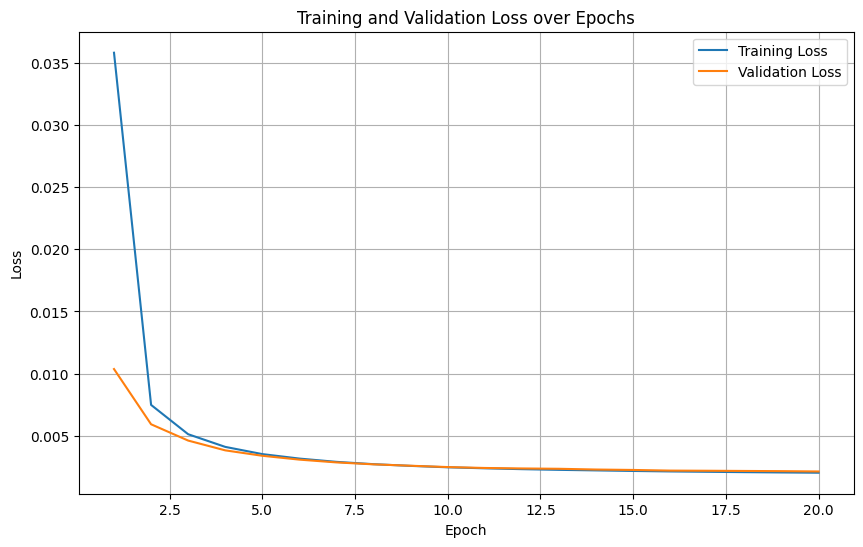

In [ ]:
import matplotlib.pyplot as plt

# Check if CUDA is available and set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

num_epochs = 20
train_losses = []
val_losses = []

print(f"Training on {device}")

for epoch in range(num_epochs):
    # Training Phase
    model.train()
    running_train_loss = 0.0
    for data in train_loader:
        inputs, _ = data
        inputs = inputs.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # Validation Phase
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for data in val_loader:
            inputs, _ = data
            inputs = inputs.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, inputs)
            running_val_loss += loss.item() * inputs.size(0)

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}')

print("Training finished.")

# Plotting the losses
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

Found a '2' (shape: torch.Size([1, 1, 28, 28])) and an '8' (shape: torch.Size([1, 1, 28, 28]))


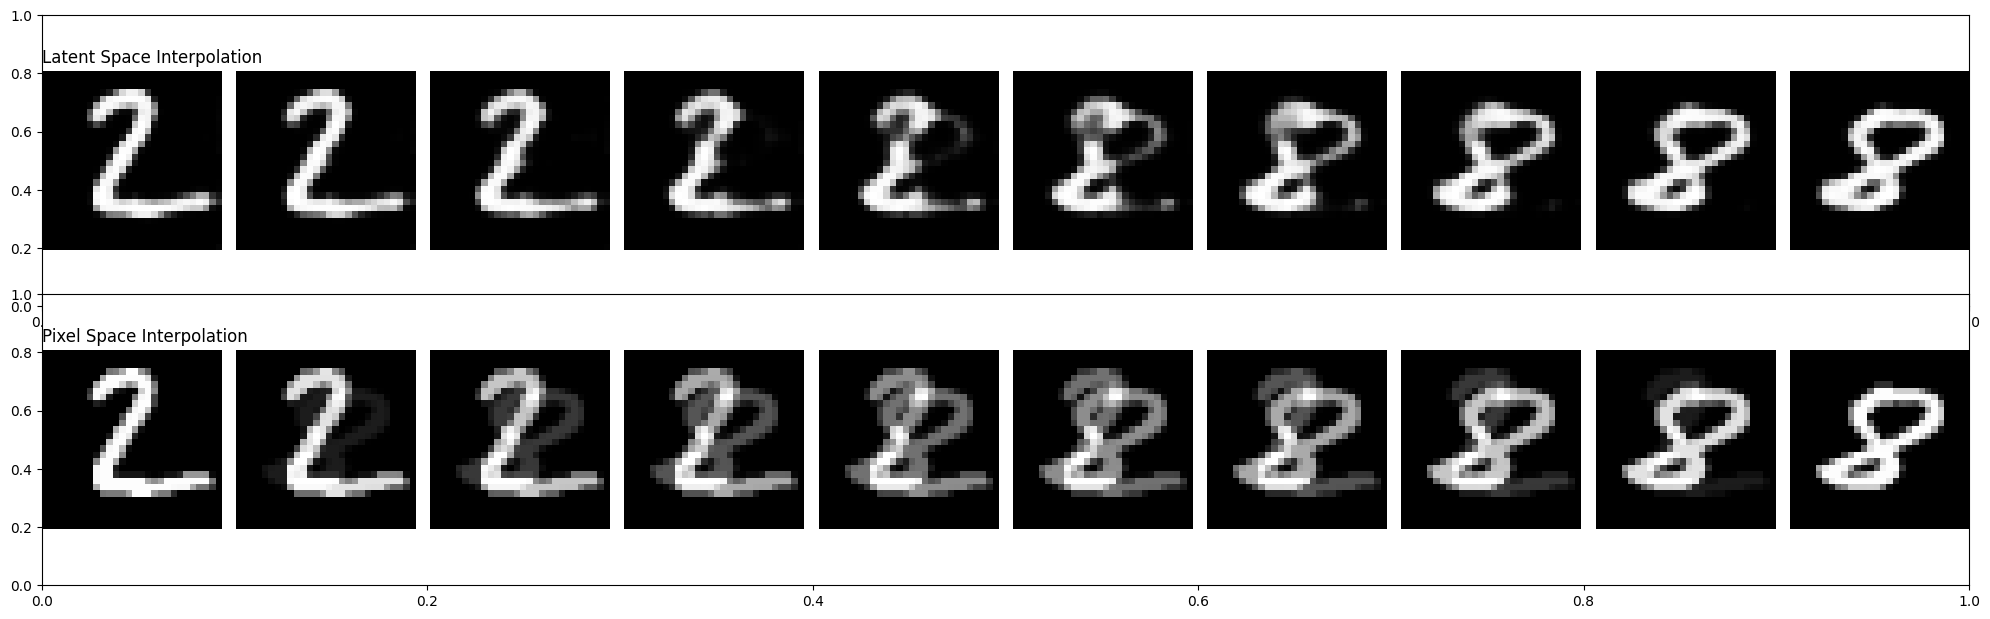

In [ ]:
import numpy as np

two_digit = None
eight_digit = None

for images, labels in test_loader:
    for i in range(len(labels)):
        if labels[i] == 2 and two_digit is None:
            two_digit = images[i].unsqueeze(0).to(device)
        if labels[i] == 8 and eight_digit is None:
            eight_digit = images[i].unsqueeze(0).to(device)
    if two_digit is not None and eight_digit is not None:
        break

if two_digit is None or eight_digit is None:
    print("Could not find both a '2' and an '8' in the test set.")
else:
    print(f"Found a '2' (shape: {two_digit.shape}) and an '8' (shape: {eight_digit.shape})")

    # Number of interpolation steps
    num_steps = 10
    interpolation_weights = np.linspace(0, 1, num_steps)

    # Move model to evaluation mode
    model.eval()

    # --- Latent Space Interpolation ---
    # Encode the two digits
    with torch.no_grad():
        latent_two = model.encoder(two_digit)
        latent_eight = model.encoder(eight_digit)

    latent_interpolations = []
    for alpha in interpolation_weights:
        interpolated_latent = latent_two * (1 - alpha) + latent_eight * alpha
        decoded_image = model.decoder(interpolated_latent)
        latent_interpolations.append(decoded_image.cpu().squeeze().detach().numpy())

    # --- Pixel Space Interpolation ---
    pixel_interpolations = []
    for alpha in interpolation_weights:
        interpolated_pixel = two_digit * (1 - alpha) + eight_digit * alpha
        pixel_interpolations.append(interpolated_pixel.cpu().squeeze().detach().numpy())

    # --- Plotting ---
    plt.figure(figsize=(num_steps * 2, 6))

    # Plot Latent Space Interpolation
    plt.subplot(2, 1, 1)
    for i in range(num_steps):
        plt.subplot(2, num_steps, i + 1)
        plt.imshow(latent_interpolations[i], cmap='gray')
        plt.axis('off')
        if i == 0: plt.title('Latent Space Interpolation', loc='left')

    # Plot Pixel Space Interpolation
    plt.subplot(2, 1, 2)
    for i in range(num_steps):
        plt.subplot(2, num_steps, num_steps + i + 1)
        plt.imshow(pixel_interpolations[i], cmap='gray')
        plt.axis('off')
        if i == 0: plt.title('Pixel Space Interpolation', loc='left')

    plt.tight_layout()
    plt.show()